# ElasticNet Regression (L1 + L2 Regularization)

## Overview
ElasticNet combines both **L1 (Lasso)** and **L2 (Ridge)** penalties into a single model. It inherits the best of both worlds:
- **Sparsity** from Lasso (some coefficients go exactly to zero)
- **Stability** from Ridge (handles correlated features gracefully)

### ElasticNet Loss Function:
$$\text{Loss} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum_{j=1}^{p}|\beta_j| + \frac{(1-\rho)}{2}\sum_{j=1}^{p}\beta_j^2 \right]$$

| Parameter | Role |
|-----------|------|
| $\alpha$  | Overall regularization strength |
| $\rho$ (`l1_ratio`) | Mix: 0 = pure Ridge, 1 = pure Lasso, 0.5 = equal mix |

| Method | Penalty | Zeros? | Best When |
|--------|---------|--------|----------|
| Ridge  | L2 only | Never  | Many small correlated features |
| Lasso  | L1 only | Yes    | Few truly important features |
| **ElasticNet** | **L1 + L2** | **Yes** | **Correlated features + sparsity needed** |

---
### Topics Covered
1. Intuition — L1 + L2 blend
2. Effect of l1_ratio on coefficients
3. Effect of alpha on sparsity
4. ElasticNetCV — joint tuning of alpha and l1_ratio
5. Correlated features — ElasticNet vs Lasso
6. Model Evaluation (MSE, MAE, R2)
7. Real-world dataset (offline-safe)
8. Full comparison: OLS vs Ridge vs Lasso vs ElasticNet
9. Coefficient path visualization


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import (
    ElasticNet, ElasticNetCV,
    Lasso, LassoCV,
    Ridge, RidgeCV,
    LinearRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_regression

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Intuition — How l1_ratio Blends Lasso and Ridge

- `l1_ratio = 0`  →  Pure Ridge (L2)
- `l1_ratio = 1`  →  Pure Lasso (L1)
- `l1_ratio = 0.5` →  Equal mix of both

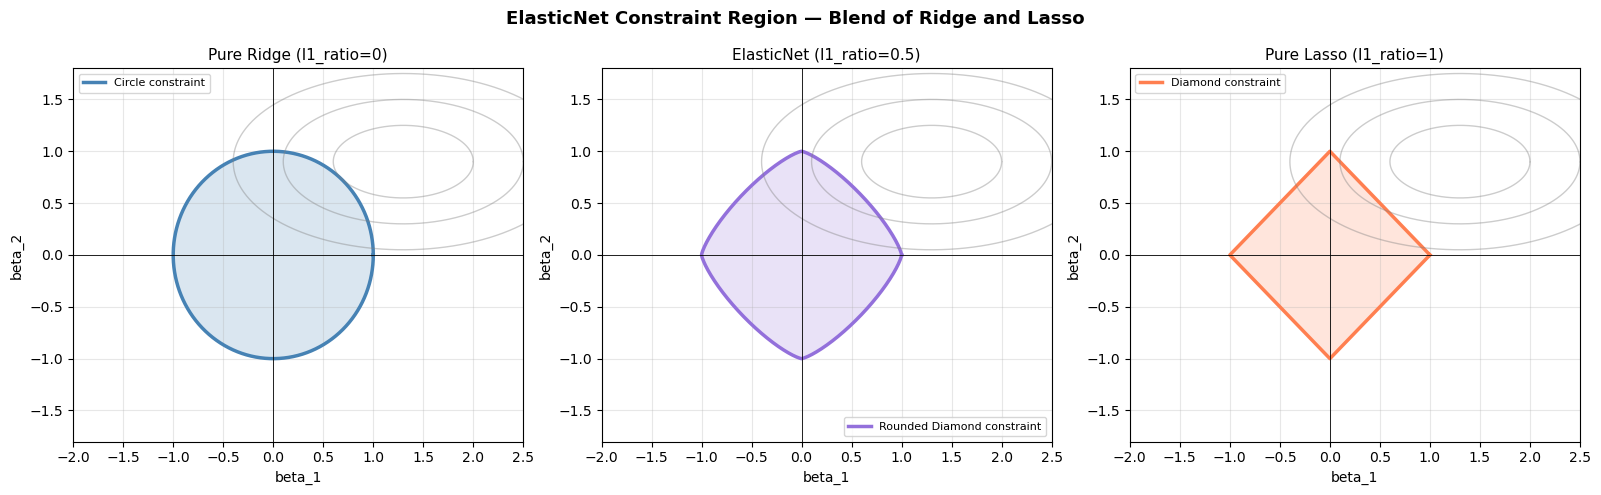

l1_ratio=0  -> Circle  -> no exact zeros  (Ridge behaviour)
l1_ratio=0.5-> Rounded -> some exact zeros (ElasticNet behaviour)
l1_ratio=1  -> Diamond -> more exact zeros (Lasso behaviour)


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
theta = np.linspace(0, 2*np.pi, 400)

configs = [
    (0.0,  'Pure Ridge (l1_ratio=0)',   'steelblue',    'Circle'),
    (0.5,  'ElasticNet (l1_ratio=0.5)', 'mediumpurple', 'Rounded Diamond'),
    (1.0,  'Pure Lasso (l1_ratio=1)',   'coral',        'Diamond'),
]

for ax, (ratio, title, color, shape) in zip(axes, configs):
    # Approximate constraint region shape
    if ratio == 0.0:
        bx = np.cos(theta)
        by = np.sin(theta)
    elif ratio == 1.0:
        bx = [1,0,-1,0,1]
        by = [0,1,0,-1,0]
    else:
        # Superellipse approximation for ElasticNet
        p  = 1.3
        bx = np.sign(np.cos(theta)) * np.abs(np.cos(theta))**(2/p)
        by = np.sign(np.sin(theta)) * np.abs(np.sin(theta))**(2/p)

    ax.fill(bx, by, alpha=0.2, color=color)
    ax.plot(bx, by, color=color, linewidth=2.5, label=f'{shape} constraint')

    # Loss contours
    for r in [0.7, 1.2, 1.7]:
        ax.plot(r*np.cos(theta)+1.3, r*0.5*np.sin(theta)+0.9,
                'gray', alpha=0.4, linewidth=1)

    ax.axhline(0, color='black', linewidth=0.6)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_xlim(-2, 2.5); ax.set_ylim(-1.8, 1.8)
    ax.set_xlabel('beta_1'); ax.set_ylabel('beta_2')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('ElasticNet Constraint Region — Blend of Ridge and Lasso',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('l1_ratio=0  -> Circle  -> no exact zeros  (Ridge behaviour)')
print('l1_ratio=0.5-> Rounded -> some exact zeros (ElasticNet behaviour)')
print('l1_ratio=1  -> Diamond -> more exact zeros (Lasso behaviour)')

## 3. Generate Dataset

In [3]:
np.random.seed(42)

X, y, true_coefs = make_regression(
    n_samples=300,
    n_features=25,
    n_informative=10,
    noise=25,
    coef=True,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

n_true        = int(np.sum(true_coefs != 0))
feature_names = [f'F{i:02d}' for i in range(X.shape[1])]

print(f'Samples          : {X.shape[0]}')
print(f'Features         : {X.shape[1]}')
print(f'Train / Test     : {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Informative      : {n_true} / {X.shape[1]}')
print(f'Noise features   : {X.shape[1] - n_true} / {X.shape[1]}')

Samples          : 300
Features         : 25
Train / Test     : 240 / 60
Informative      : 10 / 25
Noise features   : 15 / 25


## 4. Effect of l1_ratio on Coefficients

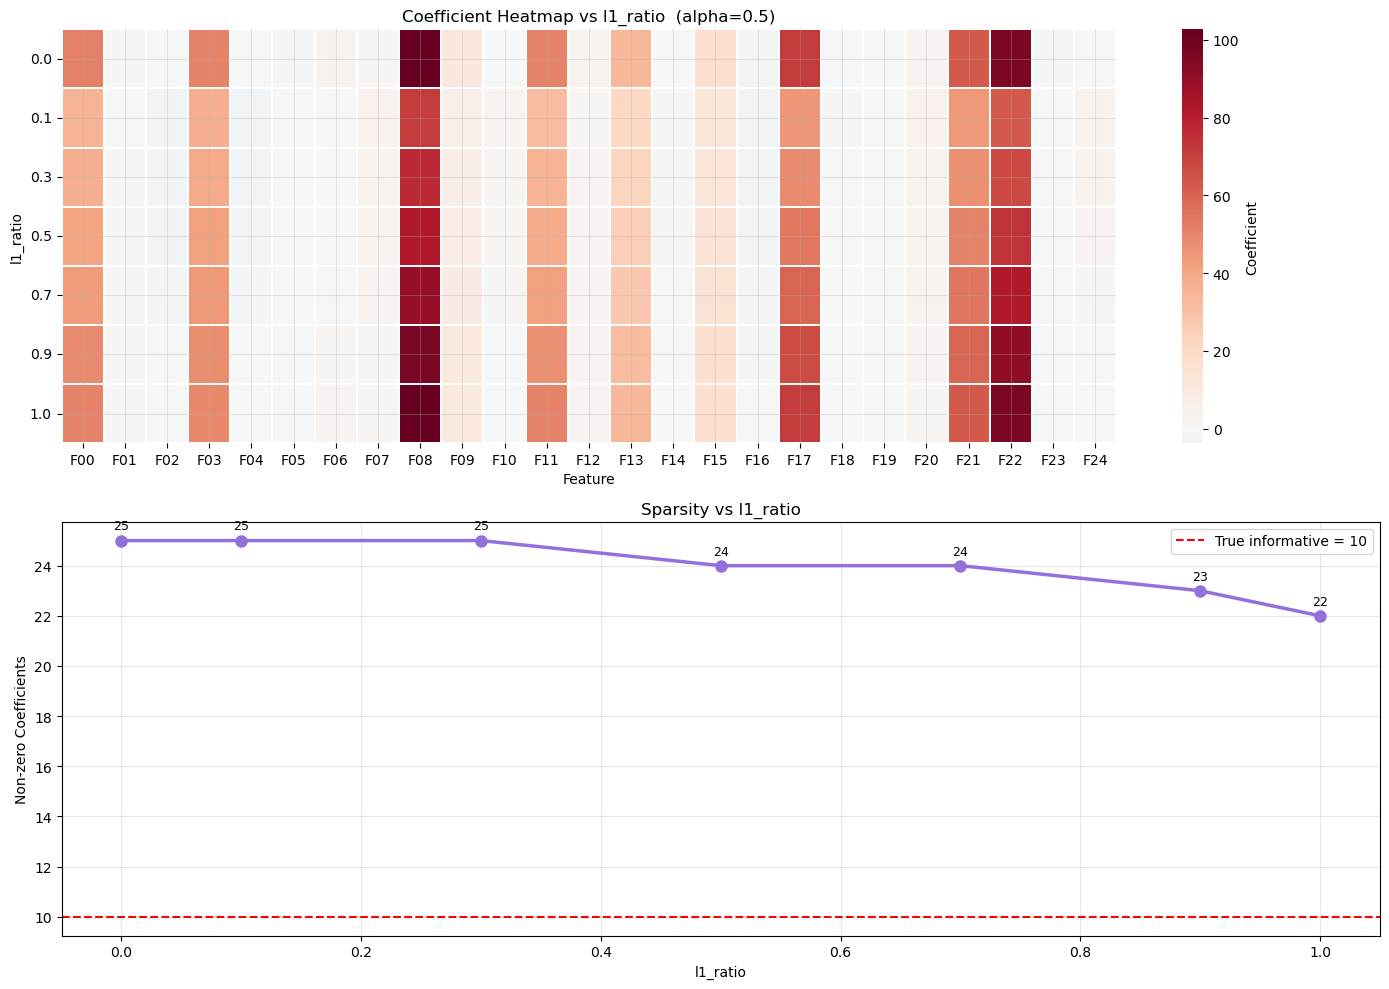

In [4]:
l1_ratios  = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
alpha_fix  = 0.5

coef_by_ratio = {}
nz_by_ratio   = []

for ratio in l1_ratios:
    if ratio == 0.0:
        m = Ridge(alpha=alpha_fix)
    elif ratio == 1.0:
        m = Lasso(alpha=alpha_fix, max_iter=10000)
    else:
        m = ElasticNet(alpha=alpha_fix, l1_ratio=ratio, max_iter=10000)
    m.fit(X_train_sc, y_train)
    coef_by_ratio[ratio] = m.coef_.copy()
    nz_by_ratio.append(int(np.sum(m.coef_ != 0)))

# Heatmap of coefficients vs l1_ratio
coef_mat = pd.DataFrame(coef_by_ratio, index=feature_names).T

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

sns.heatmap(coef_mat, cmap='RdBu_r', center=0, ax=ax1,
            linewidths=0.3, cbar_kws={'label': 'Coefficient'})
ax1.set_xlabel('Feature')
ax1.set_ylabel('l1_ratio')
ax1.set_yticklabels([str(r) for r in l1_ratios], rotation=0)
ax1.set_title(f'Coefficient Heatmap vs l1_ratio  (alpha={alpha_fix})')

ax2.plot(l1_ratios, nz_by_ratio, 'o-', color='mediumpurple',
         linewidth=2.5, markersize=8)
ax2.axhline(n_true, color='red', linestyle='--',
            linewidth=1.5, label=f'True informative = {n_true}')
for x, y_ in zip(l1_ratios, nz_by_ratio):
    ax2.annotate(str(y_), (x, y_), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9)
ax2.set_xlabel('l1_ratio')
ax2.set_ylabel('Non-zero Coefficients')
ax2.set_title('Sparsity vs l1_ratio')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Effect of Alpha on Sparsity (ElasticNet Path)

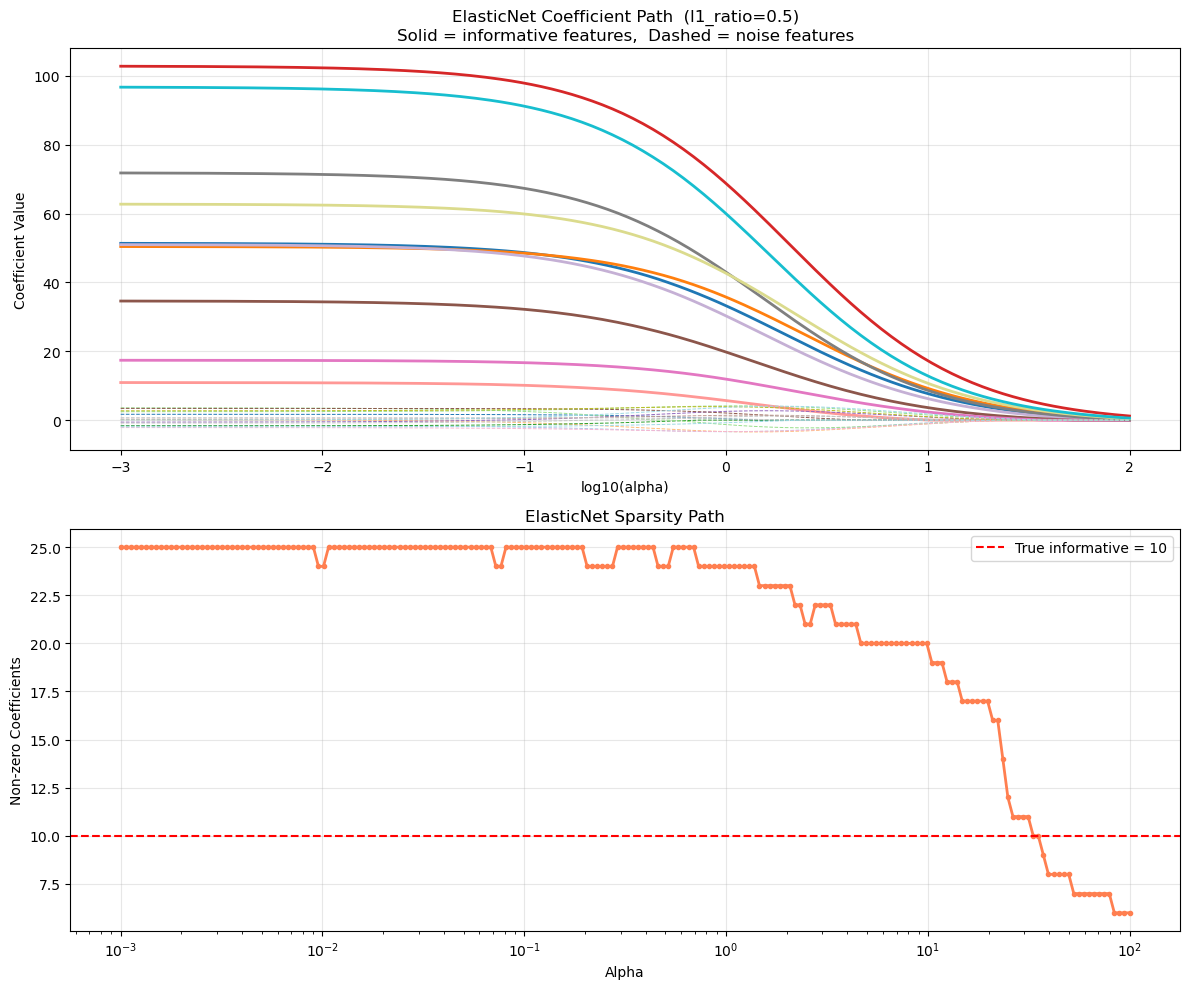

In [5]:
alphas      = np.logspace(-3, 2, 200)
l1_fix      = 0.5
coef_paths  = []
n_nonzero   = []

for alpha in alphas:
    en = ElasticNet(alpha=alpha, l1_ratio=l1_fix, max_iter=10000)
    en.fit(X_train_sc, y_train)
    coef_paths.append(en.coef_.copy())
    n_nonzero.append(int(np.sum(en.coef_ != 0)))

coef_paths = np.array(coef_paths)
colors_p   = plt.cm.tab20(np.linspace(0, 1, X.shape[1]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

for i in range(X.shape[1]):
    style = '-'  if true_coefs[i] != 0 else '--'
    lw    = 2.0  if true_coefs[i] != 0 else 0.7
    ax1.plot(np.log10(alphas), coef_paths[:, i],
             linestyle=style, linewidth=lw, color=colors_p[i])

ax1.set_xlabel('log10(alpha)')
ax1.set_ylabel('Coefficient Value')
ax1.set_title(f'ElasticNet Coefficient Path  (l1_ratio={l1_fix})\n'
               'Solid = informative features,  Dashed = noise features')

ax2.semilogx(alphas, n_nonzero, 'o-', color='coral',
             markersize=3, linewidth=2)
ax2.axhline(n_true, color='red', linestyle='--',
            linewidth=1.5, label=f'True informative = {n_true}')
ax2.set_xlabel('Alpha')
ax2.set_ylabel('Non-zero Coefficients')
ax2.set_title('ElasticNet Sparsity Path')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. ElasticNetCV — Joint Tuning of alpha and l1_ratio

Best alpha       : 0.889953
Best l1_ratio    : 1.00
Features selected: 19 / 25
Test MSE         : 673.1329
Test MAE         : 21.0958
Test R2          : 0.9807


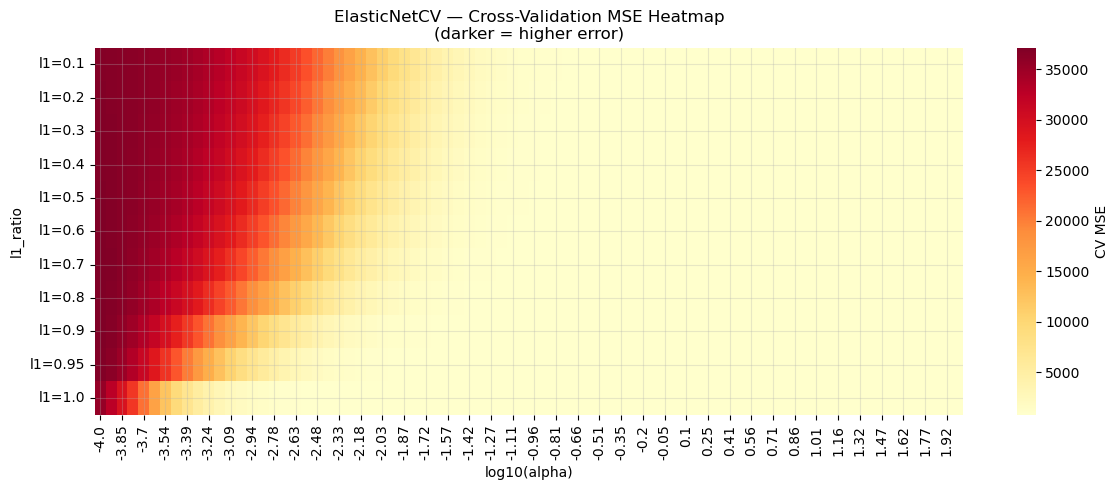

In [6]:
alphas_grid   = np.logspace(-4, 2, 80)
l1_ratios_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]

en_cv = ElasticNetCV(
    alphas=alphas_grid,
    l1_ratio=l1_ratios_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    max_iter=10000,
    n_jobs=-1
)
en_cv.fit(X_train_sc, y_train)

best_alpha = en_cv.alpha_
best_l1    = en_cv.l1_ratio_
y_pred     = en_cv.predict(X_test_sc)
n_sel      = int(np.sum(en_cv.coef_ != 0))

print(f'Best alpha       : {best_alpha:.6f}')
print(f'Best l1_ratio    : {best_l1:.2f}')
print(f'Features selected: {n_sel} / {X.shape[1]}')
print(f'Test MSE         : {mean_squared_error(y_test, y_pred):.4f}')
print(f'Test MAE         : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'Test R2          : {r2_score(y_test, y_pred):.4f}')

# CV MSE heatmap across alpha x l1_ratio
mse_grid = np.mean(en_cv.mse_path_, axis=2)   # shape: (n_l1, n_alpha)

plt.figure(figsize=(12, 5))
sns.heatmap(
    pd.DataFrame(mse_grid,
                 index=[f'l1={r}' for r in l1_ratios_grid],
                 columns=np.round(np.log10(alphas_grid), 2)),
    cmap='YlOrRd', cbar_kws={'label': 'CV MSE'}
)
plt.xlabel('log10(alpha)')
plt.ylabel('l1_ratio')
plt.title('ElasticNetCV — Cross-Validation MSE Heatmap\n(darker = higher error)')
plt.tight_layout()
plt.show()

## 7. Correlated Features — Where ElasticNet Beats Lasso

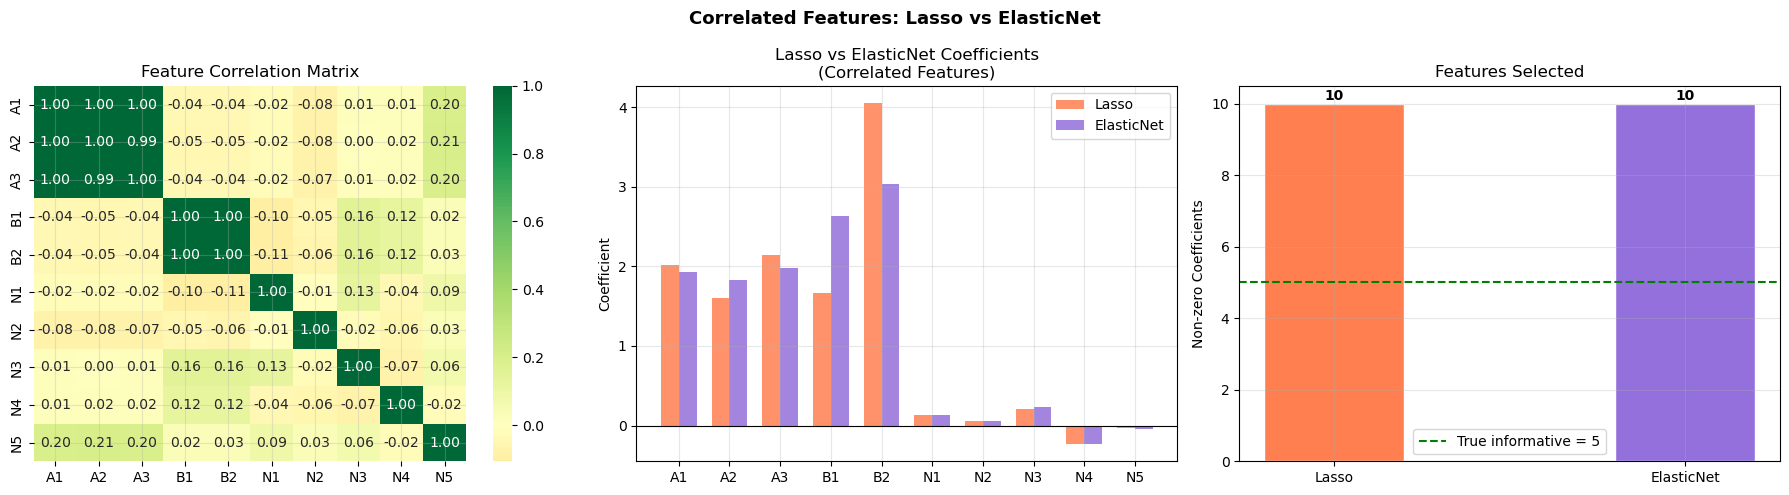

Lasso (with correlated features):
  -> Picks 10 features, may arbitrarily drop correlated ones
  -> Best alpha: 0.0277

ElasticNet (with correlated features):
  -> Picks 10 features, distributes weight across correlated group
  -> Best alpha: 0.0348,  l1_ratio: 0.30


In [7]:
# Build dataset with highly correlated feature groups
np.random.seed(10)
n = 200

# Group A: 3 correlated features (all truly important)
a1 = np.random.randn(n)
a2 = a1 + np.random.randn(n) * 0.1   # almost identical to a1
a3 = a1 + np.random.randn(n) * 0.1

# Group B: 2 correlated features (both important)
b1 = np.random.randn(n)
b2 = b1 + np.random.randn(n) * 0.1

# Noise features
noise_feats = np.random.randn(n, 5)

X_corr = np.column_stack([a1, a2, a3, b1, b2, noise_feats])
y_corr = 2*a1 + 2*a2 + 2*a3 + 3*b1 + 3*b2 + np.random.randn(n)*1.5

feat_names_c = ['A1','A2','A3','B1','B2','N1','N2','N3','N4','N5']
true_labels  = ['Informative']*5 + ['Noise']*5

X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_corr, y_corr, test_size=0.2, random_state=42
)
sc_c       = StandardScaler()
X_c_tr_sc  = sc_c.fit_transform(X_c_tr)
X_c_te_sc  = sc_c.transform(X_c_te)

# Fit Lasso and ElasticNet
lasso_c = LassoCV(cv=5, max_iter=10000).fit(X_c_tr_sc, y_c_tr)
en_c    = ElasticNetCV(
    l1_ratio=[0.3, 0.5, 0.7, 0.9],
    cv=5, max_iter=10000
).fit(X_c_tr_sc, y_c_tr)

# Correlation heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

corr_df = pd.DataFrame(X_corr, columns=feat_names_c)
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')

# Coefficient comparison
x_pos    = np.arange(len(feat_names_c))
width    = 0.35
axes[1].bar(x_pos - width/2, lasso_c.coef_, width, label='Lasso',      color='coral',        alpha=0.85)
axes[1].bar(x_pos + width/2, en_c.coef_,    width, label='ElasticNet', color='mediumpurple', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feat_names_c)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Lasso vs ElasticNet Coefficients\n(Correlated Features)')
axes[1].legend()
axes[1].set_ylabel('Coefficient')

# Non-zero counts
nz_lasso = int(np.sum(lasso_c.coef_ != 0))
nz_en    = int(np.sum(en_c.coef_ != 0))
axes[2].bar(['Lasso', 'ElasticNet'], [nz_lasso, nz_en],
            color=['coral', 'mediumpurple'], edgecolor='white', width=0.4)
axes[2].axhline(5, color='green', linestyle='--',
                linewidth=1.5, label='True informative = 5')
axes[2].set_ylabel('Non-zero Coefficients')
axes[2].set_title('Features Selected')
axes[2].legend()
for i, v in enumerate([nz_lasso, nz_en]):
    axes[2].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.suptitle('Correlated Features: Lasso vs ElasticNet', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Lasso (with correlated features):')
print(f'  -> Picks {nz_lasso} features, may arbitrarily drop correlated ones')
print(f'  -> Best alpha: {lasso_c.alpha_:.4f}')
print()
print('ElasticNet (with correlated features):')
print(f'  -> Picks {nz_en} features, distributes weight across correlated group')
print(f'  -> Best alpha: {en_c.alpha_:.4f},  l1_ratio: {en_c.l1_ratio_:.2f}')

## 8. Model Evaluation

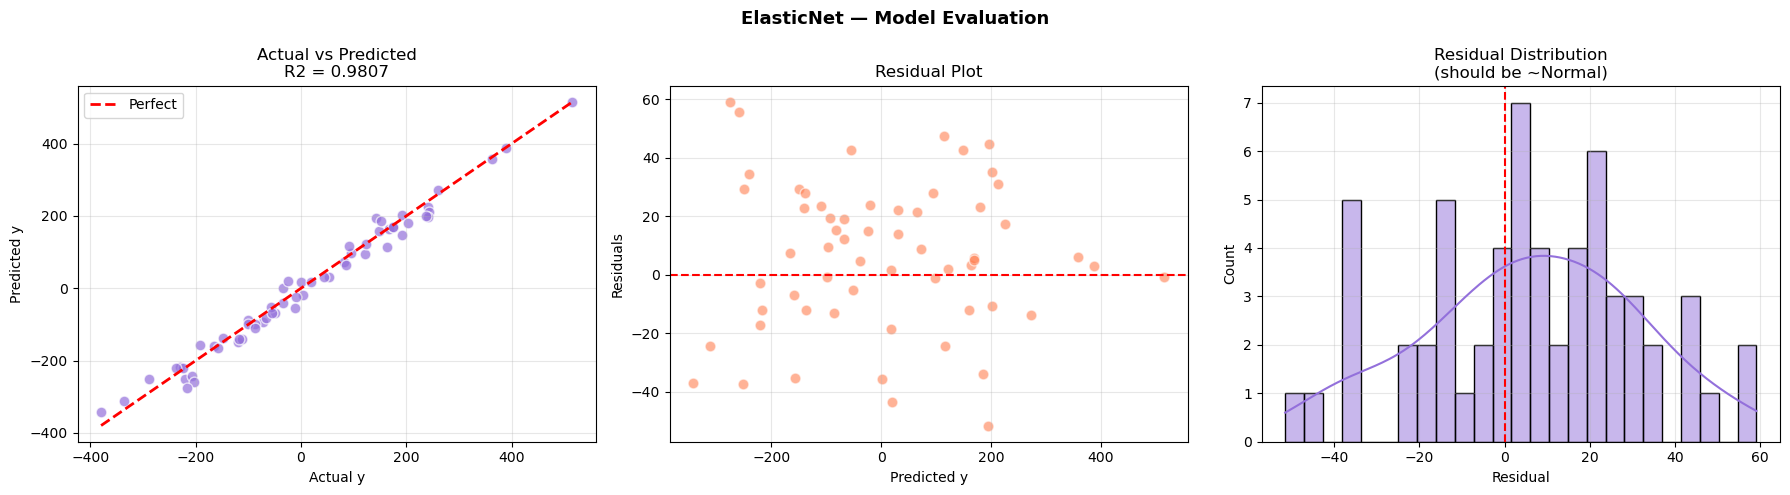

Test MSE  : 673.1329
Test MAE  : 21.0958
Test R2   : 0.9807
RMSE      : 25.9448


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7, color='mediumpurple',
                edgecolors='white', s=60)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual y'); axes[0].set_ylabel('Predicted y')
axes[0].set_title(f'Actual vs Predicted\nR2 = {r2_score(y_test, y_pred):.4f}')
axes[0].legend()

# Residuals vs Predicted
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral',
                edgecolors='white', s=60)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted y'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

# Residual distribution
sns.histplot(residuals, kde=True, color='mediumpurple', bins=25, ax=axes[2])
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual')
axes[2].set_title('Residual Distribution\n(should be ~Normal)')

plt.suptitle('ElasticNet — Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Test MSE  : {mean_squared_error(y_test, y_pred):.4f}')
print(f'Test MAE  : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'Test R2   : {r2_score(y_test, y_pred):.4f}')
print(f'RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')

## 9. Real-World Dataset — Offline Safe (Diabetes-style Synthetic)

Best alpha        : 0.129994
Best l1_ratio     : 1.00
Features selected : 6 / 10
Test MSE          : 27.5228
Test R2           : 0.8792


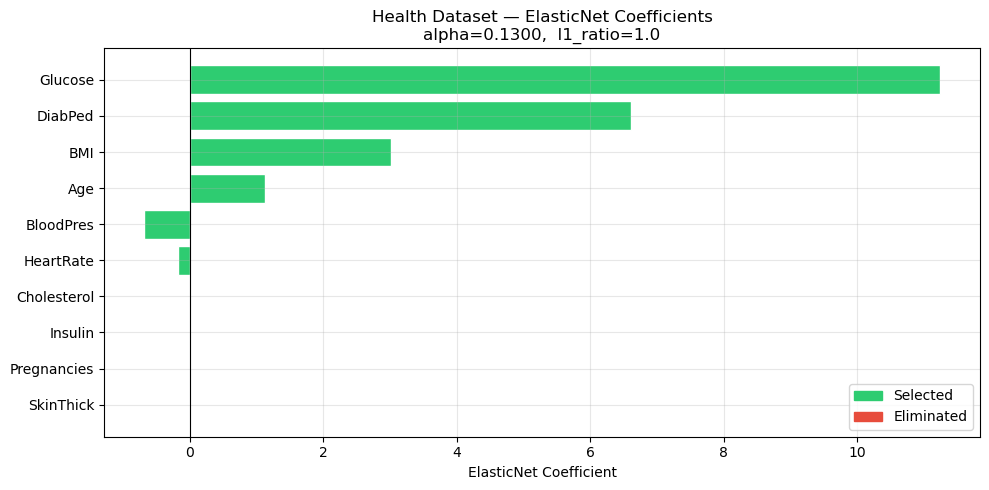

In [9]:
# Offline-safe: simulate a medical/health dataset (no download needed)
np.random.seed(7)
n_rw = 800

Age         = np.random.randint(20, 80, n_rw).astype(float)
BMI         = np.random.uniform(18, 45, n_rw)
BloodPres   = np.random.uniform(60, 120, n_rw)
Glucose     = np.random.uniform(70, 200, n_rw)
Insulin     = np.random.uniform(10, 300, n_rw)
SkinThick   = np.random.uniform(5, 60, n_rw)
DiabPed     = np.random.uniform(0.07, 2.5, n_rw)
Pregnancies = np.random.randint(0, 15, n_rw).astype(float)
Cholesterol = np.random.uniform(150, 300, n_rw)
HeartRate   = np.random.uniform(50, 100, n_rw)

feat_names_rw = ['Age','BMI','BloodPres','Glucose','Insulin',
                 'SkinThick','DiabPed','Pregnancies','Cholesterol','HeartRate']

X_rw = np.column_stack([Age, BMI, BloodPres, Glucose, Insulin,
                         SkinThick, DiabPed, Pregnancies, Cholesterol, HeartRate])

# Target: disease progression score
y_rw = (0.4*BMI + 0.3*Glucose + 0.1*Age - 0.05*BloodPres
        + 0.2*DiabPed*50 + np.random.randn(n_rw)*5)

X_rw_tr, X_rw_te, y_rw_tr, y_rw_te = train_test_split(
    X_rw, y_rw, test_size=0.2, random_state=42
)

en_rw_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 2, 80),
        cv=5, max_iter=10000
    ))
])
en_rw_pipe.fit(X_rw_tr, y_rw_tr)

best_a_rw  = en_rw_pipe.named_steps['model'].alpha_
best_l1_rw = en_rw_pipe.named_steps['model'].l1_ratio_
coefs_rw   = en_rw_pipe.named_steps['model'].coef_
preds_rw   = en_rw_pipe.predict(X_rw_te)
n_sel_rw   = int(np.sum(coefs_rw != 0))

print(f'Best alpha        : {best_a_rw:.6f}')
print(f'Best l1_ratio     : {best_l1_rw:.2f}')
print(f'Features selected : {n_sel_rw} / {len(feat_names_rw)}')
print(f'Test MSE          : {mean_squared_error(y_rw_te, preds_rw):.4f}')
print(f'Test R2           : {r2_score(y_rw_te, preds_rw):.4f}')

# Plot coefficients
coef_rw_df = pd.DataFrame({'Feature': feat_names_rw, 'Coefficient': coefs_rw})
coef_rw_df = coef_rw_df.sort_values('Coefficient', key=abs, ascending=True)
bar_colors = ['#2ecc71' if c != 0 else '#e74c3c' for c in coef_rw_df['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(coef_rw_df['Feature'], coef_rw_df['Coefficient'],
         color=bar_colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('ElasticNet Coefficient')
plt.title(f'Health Dataset — ElasticNet Coefficients\nalpha={best_a_rw:.4f},  l1_ratio={best_l1_rw}')
plt.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Selected'),
    mpatches.Patch(color='#e74c3c', label='Eliminated')
])
plt.tight_layout()
plt.show()

## 10. Full Comparison — OLS vs Ridge vs Lasso vs ElasticNet

=== Full Model Comparison ===
                     Model  Test MSE  Test R2 Non-zero coefs
                       OLS    745.42   0.9786          25/25
             Ridge (a=1.0)    742.91   0.9787          25/25
             Lasso (a=0.5)    700.39   0.9799          22/25
ElasticNet (a=0.5, l1=0.3)   3463.70   0.9007          25/25
ElasticNet (a=0.5, l1=0.5)   2380.68   0.9318          24/25
ElasticNet (a=0.5, l1=0.9)    788.21   0.9774          23/25
             ElasticNet CV    673.13   0.9807          19/25


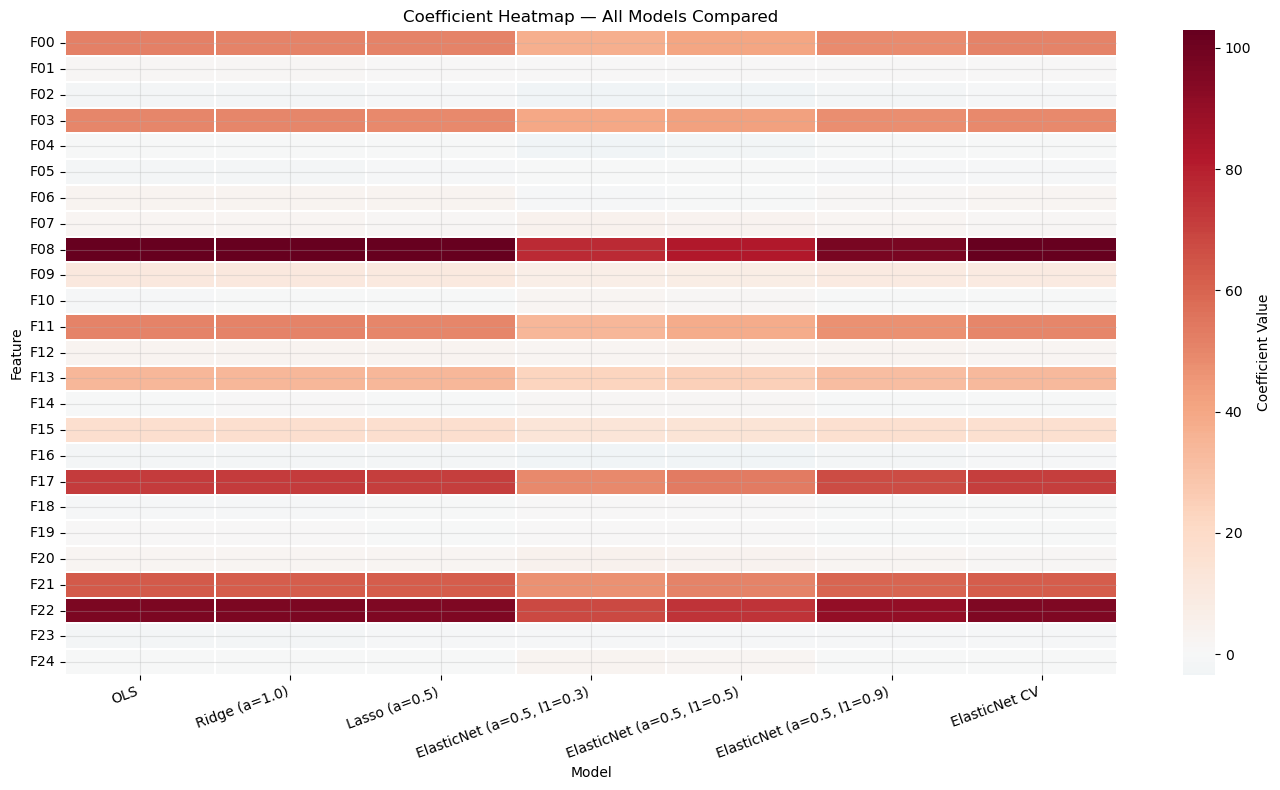

In [10]:
models = {
    'OLS':                          LinearRegression(),
    'Ridge (a=1.0)':                Ridge(alpha=1.0),
    'Lasso (a=0.5)':                Lasso(alpha=0.5, max_iter=10000),
    'ElasticNet (a=0.5, l1=0.3)':  ElasticNet(alpha=0.5, l1_ratio=0.3, max_iter=10000),
    'ElasticNet (a=0.5, l1=0.5)':  ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000),
    'ElasticNet (a=0.5, l1=0.9)':  ElasticNet(alpha=0.5, l1_ratio=0.9, max_iter=10000),
    'ElasticNet CV':                ElasticNet(alpha=best_alpha, l1_ratio=best_l1,  max_iter=10000),
}

rows      = []
all_coefs = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    n_nz  = int(np.sum(model.coef_ != 0))
    rows.append({
        'Model':          name,
        'Test MSE':       round(mean_squared_error(y_test, preds), 2),
        'Test R2':        round(r2_score(y_test, preds), 4),
        'Non-zero coefs': f'{n_nz}/{X.shape[1]}'
    })
    all_coefs[name] = model.coef_

print('=== Full Model Comparison ===')
print(pd.DataFrame(rows).to_string(index=False))

# Coefficient heatmap
coef_matrix = pd.DataFrame(all_coefs, index=feature_names)

plt.figure(figsize=(14, 8))
sns.heatmap(coef_matrix, cmap='RdBu_r', center=0,
            linewidths=0.3, cbar_kws={'label': 'Coefficient Value'})
plt.title('Coefficient Heatmap — All Models Compared')
plt.xlabel('Model'); plt.ylabel('Feature')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 11. Feature Importance — ElasticNet Coefficients

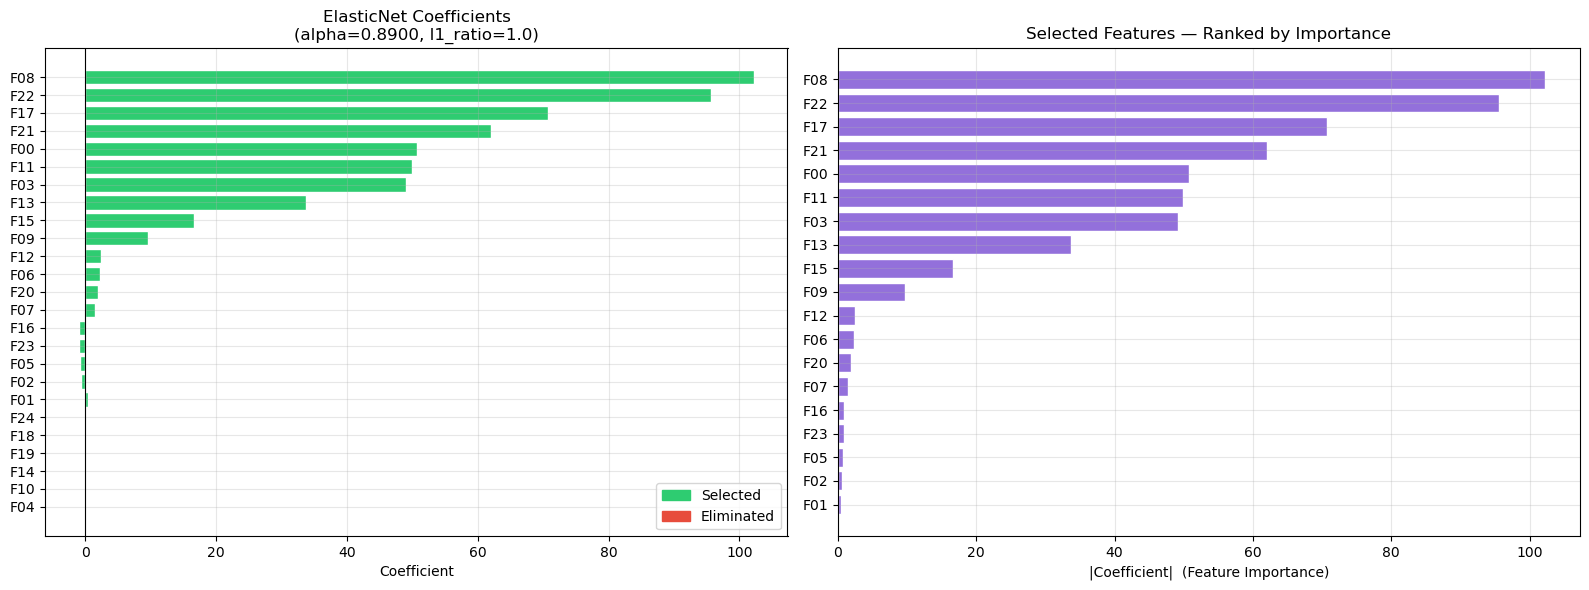

In [11]:
coef_final = en_cv.coef_
coef_fin_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coef_final,
    'AbsCoef':     np.abs(coef_final),
    'Selected':    coef_final != 0
}).sort_values('AbsCoef', ascending=True)

bar_c = ['#2ecc71' if s else '#e74c3c' for s in coef_fin_df['Selected']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Raw coefficients
ax1.barh(coef_fin_df['Feature'], coef_fin_df['Coefficient'],
         color=bar_c, edgecolor='white')
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Coefficient')
ax1.set_title(f'ElasticNet Coefficients\n(alpha={best_alpha:.4f}, l1_ratio={best_l1})')
ax1.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Selected'),
    mpatches.Patch(color='#e74c3c', label='Eliminated')
])

# Absolute coefficients (importance)
top = coef_fin_df[coef_fin_df['Selected']].sort_values('AbsCoef', ascending=True)
ax2.barh(top['Feature'], top['AbsCoef'], color='mediumpurple', edgecolor='white')
ax2.set_xlabel('|Coefficient|  (Feature Importance)')
ax2.set_title('Selected Features — Ranked by Importance')

plt.tight_layout()
plt.show()

## 12. Final Summary & Key Takeaways

In [12]:
print('=' * 65)
print('           ELASTICNET REGRESSION - KEY TAKEAWAYS')
print('=' * 65)

takeaways = [
    ('Penalty',          'L1 + L2  ->  alpha * [l1_ratio*|B| + (1-l1_ratio)/2*B^2]'),
    ('l1_ratio=0',       'Pure Ridge  ->  no zeros, all features kept'),
    ('l1_ratio=1',       'Pure Lasso  ->  sparse, some exact zeros'),
    ('l1_ratio in (0,1)','ElasticNet  ->  sparsity + stability blend'),
    ('Correlated feats', 'Ridge of correlated group, Lasso picks one — EN keeps all'),
    ('Tuning',           'Use ElasticNetCV to find best alpha AND l1_ratio jointly'),
    ('Scaling',          'ALWAYS StandardScaler before fitting ElasticNet'),
    ('Sparsity',         'Increase alpha or l1_ratio for more zero coefficients'),
    ('vs Ridge',         'ElasticNet can zero out features; Ridge cannot'),
    ('vs Lasso',         'ElasticNet is more stable with groups of correlated features'),
    ('Best use case',    'Many features, some correlated, want sparsity + stability'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<22} ->  {detail}')

print()
print(f'  Best alpha found    : {best_alpha:.6f}')
print(f'  Best l1_ratio found : {best_l1:.2f}')
print(f'  Features selected   : {n_sel} / {X.shape[1]}')
print('=' * 65)

           ELASTICNET REGRESSION - KEY TAKEAWAYS
  OK  Penalty                ->  L1 + L2  ->  alpha * [l1_ratio*|B| + (1-l1_ratio)/2*B^2]
  OK  l1_ratio=0             ->  Pure Ridge  ->  no zeros, all features kept
  OK  l1_ratio=1             ->  Pure Lasso  ->  sparse, some exact zeros
  OK  l1_ratio in (0,1)      ->  ElasticNet  ->  sparsity + stability blend
  OK  Correlated feats       ->  Ridge of correlated group, Lasso picks one — EN keeps all
  OK  Tuning                 ->  Use ElasticNetCV to find best alpha AND l1_ratio jointly
  OK  Scaling                ->  ALWAYS StandardScaler before fitting ElasticNet
  OK  Sparsity               ->  Increase alpha or l1_ratio for more zero coefficients
  OK  vs Ridge               ->  ElasticNet can zero out features; Ridge cannot
  OK  vs Lasso               ->  ElasticNet is more stable with groups of correlated features
  OK  Best use case          ->  Many features, some correlated, want sparsity + stability

  Best alpha found 

---
## Practice Exercises

1. **Sweep l1_ratio** from 0 to 1 in steps of 0.05 and plot Test MSE vs l1_ratio for a fixed alpha.
2. **Add more correlated feature groups** and compare how many Lasso drops vs ElasticNet keeps.
3. **Pipeline with PolynomialFeatures** — use ElasticNetCV after degree-2 expansion.
4. **Manual grid search** — nest two for-loops over alpha and l1_ratio and build a 2D MSE surface.
5. **Compare ElasticNetCV runtime** vs separate LassoCV + RidgeCV — which is faster and why?
6. **Implement ElasticNet from scratch** using coordinate descent and verify it matches sklearn.

---
*Notebook created for the ML Repository — ElasticNet Regression module.*